<a href="https://colab.research.google.com/github/mahoneyjustinnj/myGarminHealth_JM/blob/main/analyzingGarminHeartDataColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [169]:
# from google.colab import ai
# response = ai.generate_text("What is the capital of France?")

In [171]:
#$$
# suppressMessages(install.packages("tidyverse"))
# suppressMessages(install.packages("lubridate"))
# suppressMessages(install.packages("FSA"))
# suppressMessages(install.packages("RColorBrewer"))
# suppressMessages(install.packages("dplyr"))
# suppressMessages(install.packages("plotly"))
# suppressMessages(install.packages("ggplot2"))
# suppressMessages(install.packages("ggpubr"))
# suppressMessages(install.packages("skimr"))
# suppressMessages(install.packages("tibble"))
# suppressMessages(install.packages("htmltools"))
# suppressMessages(install.packages("tibbletime"))
# suppressMessages(install.packages("zoo"))
# suppressMessages(install.packages("tidyr"))
# suppressMessages(install.packages("anomalize"))
# suppressMessages(install.packages("knitr"))
# suppressMessages(install.packages("gt"))
# suppressMessages(install.packages("stringr"))
# suppressMessages(install.packages("grid"))
#$$
# Suppress package installation messages
suppressMessages(suppressWarnings({
  library(tidyverse)       # Data manipulation and visualization (includes dplyr, ggplot2, etc.)
  library(lubridate)       # Date and time manipulation functions
  library(FSA)             # Fisheries Stock Assessment - includes statistical tests like Dunn's test
  library(RColorBrewer)    # Color palettes for plots
  library(dplyr)           # Data frame manipulation (part of tidyverse, loaded explicitly for clarity)
  library(plotly)          # Interactive plotting library
  library(ggplot2)         # Static plotting (part of tidyverse, loaded explicitly)
  library(ggpubr)          # Publication-ready ggplot2 figures
  library(skimr)           # Quick data summary function
  library(tibble)          # Modern data frame format
  library(htmltools)       # HTML utilities for Shiny/markdown
  library(tibbletime)      # Time-aware tibbles for time series
  library(zoo)             # Time series and irregular data handling (includes na.approx)
  library(tidyr)           # Data reshaping (pivot_wider, unnest, etc.)
  library(anomalize)       # Time series anomaly detection
  library(knitr)           # R Markdown processing
  library(gt)              # Great Tables - nice table formatting
  library(stringr)         # String manipulation functions
  library(grid)            # Low-level graphics utilities
}))
#$$
knitr::opts_chunk$set(
  warning = FALSE,    # Suppress warning messages during knitting
  message = FALSE     # Suppress informational messages during knitting
)

In [172]:
#$$
# cat("\014")  # Clear console (commented out)
gc()                                                    # Garbage collection - free up memory

rm(list = ls())                                         # Remove all objects from environment

setwd("/content")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3318523,177.3,5593811,298.8,5593811,298.8
Vcells,10235636,78.1,32594098,248.7,32594015,248.7


In [173]:
# Don't use vroom or tidyverse - just base R
Sys.setenv("VROOM_CONNECTION_SIZE" = 5000000)

file_path <- "garmin_combined_summaries_from_2026-01-02.csv"

# Read just the header (first row)
header <- read.csv(file_path, nrows = 1, stringsAsFactors = FALSE)

cat("=== FILE DIAGNOSTICS ===\n")
cat("Total columns:", ncol(header), "\n")
cat("Total column name characters:", sum(nchar(colnames(header))), "\n\n")

# Find duplicate column names
col_freq <- table(colnames(header))
duplicates <- names(col_freq[col_freq > 1])

cat("Duplicate columns found:", length(duplicates), "\n")
if(length(duplicates) > 0) {
  cat("\nDuplicate column names and their frequencies:\n")
  print(col_freq[col_freq > 1])
}

# Show first 20 column names
cat("\n\nFirst 20 column names:\n")
print(colnames(header)[1:20])

# Show last 20 column names
cat("\n\nLast 20 column names:\n")
print(colnames(header)[(ncol(header)-19):ncol(header)])

=== FILE DIAGNOSTICS ===
Total columns: 53 
Total column name characters: 1074 

Duplicate columns found: 0 


First 20 column names:
 [1] "summaryDate"                      "userProfilePK"                    "calendarDate"                     "startTimestampGMT"                "endTimestampGMT"                  "startTimestampLocal"              "endTimestampLocal"                "maxHeartRate"                    
 [9] "minHeartRate"                     "restingHeartRate"                 "lastSevenDaysAvgRestingHeartRate" "heartRateValueDescriptors"        "heartRateValues"                  "userProfilePk"                    "hrvSummary"                       "hrvReadings"                     
[17] "sleepStartTimestampGMT"           "sleepEndTimestampGMT"             "sleepStartTimestampLocal"         "sleepEndTimestampLocal"          


Last 20 column names:
 [1] "respirationVersion"                   "dailySleepDTO"                        "sleepMovement"                        "remS

In [174]:
Sys.setenv("VROOM_CONNECTION_SIZE" = 5000000)

# file_path <- "garmin_combined_summaries_from_2026-01-02.csv"

# # Read with base R
# data <- read.csv(file_path, stringsAsFactors = FALSE)

# cat("File loaded successfully!\n")
# cat("Dimensions:", nrow(data), "rows x", ncol(data), "columns\n")
# cat("Column names:\n")
# print(colnames(data))

# # Preview first row
# cat("\n\nFirst row preview:\n")
# str(data[1, ])

In [175]:
# # Select just the health metrics you need
# health_data <- data.frame(
#   date = data$calendarDate,
#   max_hr = data$maxHeartRate,
#   min_hr = data$minHeartRate,
#   resting_hr = data$restingHeartRate,
#   sleep_start = data$sleepStartTimestampLocal,
#   sleep_end = data$sleepEndTimestampLocal,
#   hrv_summary = data$hrvSummary,
#   sleep_heart_rate = data$sleepHeartRate,
#   sleep_stress = data$sleepStress,
#   sleep_body_battery = data$sleepBodyBattery
# )

# head(health_data)

##This reads in the data

In [176]:
Sys.setenv("VROOM_CONNECTION_SIZE" = 5000000)

needed_cols <- c(
  # Dates
  "calendarDate", "summaryDate",
  # Heart Rate
  "heartRateValues", "heartRateValueDescriptors",
  "maxHeartRate", "minHeartRate", "restingHeartRate", "lastSevenDaysAvgRestingHeartRate",
  # HRV
  "userProfilePK", "userProfilePk",
  "startTimestampGMT", "endTimestampGMT", "startTimestampLocal", "endTimestampLocal",
  "hrvSummary", "hrvReadings",
  # Sleep
  "sleepStartTimestampGMT", "sleepEndTimestampGMT",
  "sleepStartTimestampLocal", "sleepEndTimestampLocal",
  "tomorrowSleepStartTimestampGMT", "tomorrowSleepEndTimestampGMT",
  "tomorrowSleepStartTimestampLocal", "tomorrowSleepEndTimestampLocal",
  # Respiration
  "lowestRespirationValue", "highestRespirationValue",
  "avgWakingRespirationValue", "avgSleepRespirationValue", "avgTomorrowSleepRespirationValue"
)

df_raw <- read.csv("garmin_combined_summaries_from_2026-01-02.csv",
                    colClasses = "character")

# Keep only needed columns
df <- df_raw[, intersect(colnames(df_raw), needed_cols)]

cat("Loaded:", nrow(df), "rows x", ncol(df), "columns\n")
head(df)

Loaded: 136 rows x 29 columns


,summaryDate,userProfilePK,calendarDate,startTimestampGMT,endTimestampGMT,startTimestampLocal,endTimestampLocal,maxHeartRate,minHeartRate,restingHeartRate,⋯,sleepEndTimestampLocal,tomorrowSleepStartTimestampGMT,tomorrowSleepEndTimestampGMT,tomorrowSleepStartTimestampLocal,tomorrowSleepEndTimestampLocal,lowestRespirationValue,highestRespirationValue,avgWakingRespirationValue,avgSleepRespirationValue,avgTomorrowSleepRespirationValue
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,2025-08-20,136631288,2025-08-20,2025-08-20T04:00:00.0,2025-08-21T04:00:00.0,2025-08-20T00:00:00.0,2025-08-21T00:00:00.0,,,52,⋯,2025-08-20T07:44:40.0,2025-08-21T04:38:17.0,2025-08-21T11:40:17.0,2025-08-21T00:38:17.0,2025-08-21T07:40:17.0,7.0,24.0,16.0,13.0,17.0
2,2025-08-21,136631288,2025-08-21,2025-08-21T04:00:00.0,2025-08-22T04:00:00.0,2025-08-21T00:00:00.0,2025-08-22T00:00:00.0,,,59,⋯,2025-08-21T07:40:17.0,2025-08-22T04:54:54.0,2025-08-22T11:36:16.0,2025-08-22T00:54:54.0,2025-08-22T07:36:16.0,7.0,24.0,17.0,17.0,16.0
3,2025-08-22,136631288,2025-08-22,2025-08-22T04:00:00.0,2025-08-23T04:00:00.0,2025-08-22T00:00:00.0,2025-08-23T00:00:00.0,,,52,⋯,2025-08-22T07:36:16.0,2025-08-23T04:38:11.0,2025-08-23T12:39:11.0,2025-08-23T00:38:11.0,2025-08-23T08:39:11.0,9.0,25.0,17.0,16.0,15.0
4,2025-08-23,136631288,2025-08-23,2025-08-23T04:00:00.0,2025-08-24T04:00:00.0,2025-08-23T00:00:00.0,2025-08-24T00:00:00.0,,,56,⋯,2025-08-23T08:39:11.0,2025-08-24T05:10:39.0,2025-08-24T11:55:39.0,2025-08-24T01:10:39.0,2025-08-24T07:55:39.0,7.0,24.0,18.0,15.0,16.0
5,2025-08-24,136631288,2025-08-24,2025-08-24T04:00:00.0,2025-08-25T04:00:00.0,2025-08-24T00:00:00.0,2025-08-25T00:00:00.0,,,58,⋯,2025-08-24T07:55:39.0,2025-08-25T04:52:18.0,2025-08-25T10:18:18.0,2025-08-25T00:52:18.0,2025-08-25T06:18:18.0,9.0,25.0,18.0,16.0,16.0
6,2025-08-25,136631288,2025-08-25,2025-08-25T04:00:00.0,2025-08-26T04:00:00.0,2025-08-25T00:00:00.0,2025-08-26T00:00:00.0,,,54,⋯,2025-08-25T06:18:18.0,2025-08-26T03:54:29.0,2025-08-26T09:47:43.0,2025-08-25T23:54:29.0,2025-08-26T05:47:43.0,8.0,24.0,17.0,16.0,15.0


##This creates the functions

In [177]:
#$$
# df_raw <- read_csv("garmin_combined_summaries_from_2026-01-02.csv")
# df <- df_raw
# Display first n rows of dataframe with gt styling and header
show_tb <- function(df, n = 6) {
  library(gt)

  df %>%
    head(n) %>%                          # Get first n rows
    gt() %>%                             # Convert to gt table object
    tab_header(
      title = paste("Showing First", n, "Rows"),      # Add title with dynamic row count
      subtitle = "Styled with gt"                      # Add subtitle
    )
}
#$$
# Track dataframes and their columns in all_names data structure
fx <- function(...  ) {
  arg_exprs <- substitute(list(...))[-1]  # Capture unevaluated arguments as expressions
  i <- 1                                   # Initialize loop counter

  while (i <= length(arg_exprs)) {
    expr <- arg_exprs[[i]]                 # Get current expression
    is_comment <- FALSE                    # Flag for comment detection (unused)

    # Skip comment-only arguments
    if (is.character(expr)) {
      i <- i + 1
      next                                 # Move to next iteration if argument is character string
    }

    df_name <- deparse(expr)               # Convert expression to character string (dataframe name)
    comment <- ""                          # Initialize comment variable

    # Check if next argument is a comment string
    if (i < length(arg_exprs) && is.character(arg_exprs[[i + 1]])) {
      comment <- eval(arg_exprs[[i + 1]], envir = .GlobalEnv)  # Evaluate next arg as comment
      i <- i + 1                           # Skip the comment in next iteration
    }

    # Evaluate dataframe existence and get column names
    df_exists <- exists(df_name, envir = .GlobalEnv)  # Check if dataframe exists in global environment
    if (df_exists) {
      df <- get(df_name, envir = .GlobalEnv)         # Retrieve the dataframe object
      if (!inherits(df, "data.frame")) {
        message(df_name, " exists but is not a dataframe.   Skipping.")
        i <- i + 1
        next                               # Skip if not a dataframe
      }
      col_list <- paste(names(df), collapse = ", ")  # Get all column names as comma-separated string
    } else {
      col_list <- ""                       # Empty string if dataframe doesn't exist
      comment <- paste0("object '", df_name, "' not found\n", comment)  # Add error message to comment
      message(df_name, " is not present in environment but added to all_names.")
    }

    # Add or update entry in tracking dataframe
    idx <- which(all_names$dataframe == df_name)     # Find if dataframe already tracked
    if (length(idx) == 1) {
      if (comment != "") {
        all_names$comment[idx] <<- paste(all_names$comment[idx], comment, sep = "\n")  # Append comment
      }
      if (col_list != "") {
        all_names$columns[idx] <<- col_list          # Update columns if not empty
      }
    } else {
      all_names <<- rbind(
        all_names,
        data.frame(dataframe = df_name, columns = col_list, comment = comment, stringsAsFactors = FALSE)
      )                                    # Add new row to all_names tracking table
    }

    i <- i + 1                             # Increment counter
  }

  # Reorder:  move rows with empty columns to bottom
  empty_rows <- which(all_names$columns == "")       # Find rows with no columns (missing dataframes)
  filled_rows <- which(all_names$columns != "")      # Find rows with columns (existing dataframes)
  all_names <<- all_names[c(filled_rows, empty_rows), ]  # Reorder:  existing first, missing last
}

#$$
# Compare column names between dataframes
comp_cols <- function(df_raw, ..., reverse = FALSE) {
  # Capture exclusions as character strings
  exclude <- as.character(substitute(list(... )))[-1]

  # Get column names from df_raw
  df_names <- names(df_raw)

  # Filter all_names based on exclude list
  if (length(exclude) > 0) {
    all_names_filtered <- all_names[!(all_names[[1]] %in% exclude), ]
  } else {
    all_names_filtered <- all_names
  }

  # Parse and clean all comma-separated column names
  ref_names <- unlist(strsplit(paste(all_names_filtered[[2]], collapse = ","), ","))
  ref_names_clean <- trimws(ref_names)

  # Return either missing or extra columns based on reverse flag
  if (reverse) {
    return(ref_names_clean[!(ref_names_clean %in% df_names)])
  } else {
    return(df_names[!(df_names %in% ref_names_clean)])
  }
}

#$$
# Initialize empty tracking dataframe
all_names <- data.frame(
  dataframe = character(0),
  columns = character(0),
  comment = character(0),
  stringsAsFactors = FALSE
)

#$$
# Add or append comment to tracked dataframe
add_comment <- function(df, comment) {
  # Convert dataframe argument to string to get its name
  df_name <- deparse(substitute(df))

  # Search all_names for row matching the dataframe name
  idx <- which(all_names$dataframe == df_name)

  # If dataframe found in all_names (should be exactly one match)
  if (length(idx) == 1) {
    # Check if comment field is currently empty
    if (all_names$comment[idx] == "") {
      # If empty, assign comment directly to the dataframe row
      all_names$comment[idx] <<- comment
    } else {
      # If comment already exists, append new comment with newline separator
      all_names$comment[idx] <<- paste(all_names$comment[idx], comment, sep = "\n")
    }
  }
}
#$$
# Clear all tracked dataframes in all_names
reset_fx <- function() {
  # Reassign all_names to empty dataframe with same structure
  all_names <<- data.frame(
    dataframe = character(0),  # Empty character vector for dataframe names
    columns = character(0),    # Empty character vector for column lists
    comment = character(0),    # Empty character vector for comments
    stringsAsFactors = FALSE   # Prevent automatic conversion of strings to factors
  )
}

#$$
# Display comments for a specific dataframe
df_comms <- function(df) {
  # Convert dataframe argument to string to get its name
  df_name <- deparse(substitute(df))

  # Search all_names for row matching the dataframe name
  idx <- which(all_names$dataframe == df_name)

  # If dataframe not found in all_names or comment field is empty
  if (length(idx) == 0 || all_names$comment[idx] == "") {
    # Print message indicating no comments exist for this dataframe
    message("There are no comments currently for this dataframe.")
  } else {
    # If comments exist, print them to console
    cat(all_names$comment[idx])
  }
}

#$$
# List all current dataframe objects in environment
curr_df <- function(env = .GlobalEnv) {
  # Get list of all object names in the specified environment
  objs <- ls(envir = env)

  # Filter objects to keep only those that are dataframes or dataframe-like objects
  df_objs <- Filter(function(x) {
    # Retrieve object from environment
    obj <- get(x, envir = env)

    # Check if object inherits from data.frame, tbl_df, or data.table classes
    inherits(obj, c("data.frame", "tbl_df", "data.table"))
  }, objs)

  # If no dataframes found in environment
  if (length(df_objs) == 0) {
    # Print message indicating no data-holding objects were found
    message("No data-holding objects found.")
  } else {
    # If dataframes found, print their names to console
    print(df_objs)
  }
}

#$$
# Find untracked dataframes in environment
misd_df <- function() {
  # Get current data-holding objects from environment
  current_dfs <- curr_df()

  # If no dataframes exist, return invisibly without printing anything
  if (is.null(current_dfs)) return(invisible(NULL))

  # Get list of already tracked dataframes from all_names
  tracked_dfs <- all_names$dataframe

  # Find dataframes that exist but are not in all_names (untracked)
  missing <- setdiff(current_dfs, tracked_dfs)

  # If all dataframes are already tracked
  if (length(missing) == 0) {
    # Print message indicating all dataframes are tracked
    message("All current dataframes are already tracked in all_names.")
  } else {
    # If untracked dataframes found, print header message
    cat("Untracked dataframes:\n")

    # Print list of untracked dataframes
    print(missing)
  }
}

In [178]:

# options(width = 200)  # Increase console width
# head(df)
# Set options to show all columns
options(width = 300, max.print = 10000)

# Use glimpse() with explicit width
library(dplyr)
glimpse(df, width = 500)

Rows: 136
Columns: 29
$ summaryDate                      <chr> "2025-08-20", "2025-08-21", "2025-08-22", "2025-08-23", "2025-08-24", "2025-08-25", "2025-08-26", "2025-08-27", "2025-08-28", "2025-08-29", "2025-08-30", "2025-08-31", "2025-09-01", "2025-09-02", "2025-09-03", "2025-09-04", "2025-09-05", "2025-09-06", "2025-09-07", "2025-09-08", "2025-09-09", "2025-09-10", "2025-09-11", "2025-09-12", "2025-09-13", "2025-09-14", "2025-09-15", "2025-09-16", "2025-09-17", "2025-09-18", "2025-09-19", "2025-09-20", "2025-09-…
$ userProfilePK                    <chr> "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "1366312

In [179]:

# options(width = 200)  # Increase console width
# head(df)
# Set options to show all columns
options(width = 300, max.print = 10000)

# Use glimpse() with explicit width
library(dplyr)
glimpse(df, width = 500)

Rows: 136
Columns: 29
$ summaryDate                      <chr> "2025-08-20", "2025-08-21", "2025-08-22", "2025-08-23", "2025-08-24", "2025-08-25", "2025-08-26", "2025-08-27", "2025-08-28", "2025-08-29", "2025-08-30", "2025-08-31", "2025-09-01", "2025-09-02", "2025-09-03", "2025-09-04", "2025-09-05", "2025-09-06", "2025-09-07", "2025-09-08", "2025-09-09", "2025-09-10", "2025-09-11", "2025-09-12", "2025-09-13", "2025-09-14", "2025-09-15", "2025-09-16", "2025-09-17", "2025-09-18", "2025-09-19", "2025-09-20", "2025-09-…
$ userProfilePK                    <chr> "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "1366312

In [180]:
#$$
# Extract calendar date and heart rate values columns
dtwp <- df %>%
  select(calendarDate, heartRateValues)

dtwp <- dtwp %>%
  mutate(
    heartRateValues = ifelse(heartRateValues == "", "[]", heartRateValues),
    heartRateValues = trimws(heartRateValues)
  )

fx(dtwp, "takes these 2 columns from df - CLEANED")

de <- df %>%
  select(-heartRateValues, -heartRateValueDescriptors)

fx(de, "de takes everything from df except heartRateValues and heartRateValueDescriptors")

#$$
dtwp1 <- dtwp %>%
  mutate(heartRateValues = map(heartRateValues, ~ {
    tryCatch({
      .x <- gsub("None", "null", .x)
      parsed_data <- jsonlite::fromJSON(.x)
      return(parsed_data)
    }, error = function(e) {
      message(paste("Warning:  Failed to parse JSON"))
      return(data.frame(timestamp = numeric(0), heartrate = numeric(0)))
    })
  }))

fx(dtwp1, "dtwp1 parses JSON - WITH ERROR HANDLING")

#$$
dtwp2 <- dtwp1 %>%
  {
    rows_list <- list()
    for (i in seq_len(nrow(.  ))) {
      parsed <- . [[i, "heartRateValues"]]

      if (is.null(parsed) || length(parsed) == 0) {
        next
      } else if (is.matrix(parsed)) {
        df_temp <- as.data.frame(parsed)
        colnames(df_temp) <- c("seconds", "heartrate")
        df_temp$calendarDate <- . [[i, "calendarDate"]]
        rows_list[[i]] <- df_temp
      }
    }

    bind_rows(rows_list)
  }

fx(dtwp2, "dtwp2 extracts heartRateValues from matrix format")

#$$
data <- dtwp2 %>%
  mutate(
    time = as.POSIXct(seconds / 1000, origin = "1970-01-01", tz = "UTC"),
    time = with_tz(time, tzone = "America/Toronto"),
    heartrate = na.approx(heartrate, na.rm = FALSE)
  ) %>%
  select(calendarDate, time, heartrate)

fx(data, "data converted timestamps to Eastern Time")

#$$
#show_tb(data, 10)

#$$
cat("Data date range:\n")
cat("Min date:", format(min(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Max date:", format(max(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Total rows:", nrow(data), "\n")

Data date range:
Min date: 2025-08-31 
Max date: 2026-01-02 
Total rows: 86793 


In [181]:
print("done to here")

[1] "done to here"


# done to here

In [182]:
head(data)

,calendarDate,time,heartrate
,<chr>,<dttm>,<dbl>
1,2025-09-01,2025-08-31 23:00:00,75
2,2025-09-01,2025-08-31 23:02:00,71
3,2025-09-01,2025-08-31 23:04:00,80
4,2025-09-01,2025-08-31 23:06:00,73
5,2025-09-01,2025-08-31 23:08:00,75
6,2025-09-01,2025-08-31 23:10:00,70


In [183]:
#$$
# data already created from dtwp2 with columns: calendarDate, time, heartrate
# Just rename and reorder columns for clarity

data <- data %>%
  rename(
    date = calendarDate
  ) %>%
  select(date, time, heartrate)

# Track data dataframe with description
fx(data, "data renamed and reordered columns:  date, time, heartrate")

#$$
# Display first few rows of processed data
#show_tb(data, 10)



In [184]:
#$$
# Check the date range in your data
#$$
# Check the date range in your data
cat("Data date range:\n")
cat("Min date:", format(min(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Max date:", format(max(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Total rows:", nrow(data), "\n")

Data date range:
Min date: 2025-08-31 
Max date: 2026-01-02 
Total rows: 86793 


In [185]:

#$$
# Display first few rows of processed data
# show_tb(data, 1)
#$$
# Check the date range in your data
cat("Data date range:\n")
cat("Min date:", format(min(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Max date:", format(max(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Total rows:", nrow(data), "\n")
#$$
# Extract daily heart rate statistics from de dataframe
de1 <- de %>% select(calendarDate, maxHeartRate, minHeartRate, restingHeartRate, lastSevenDaysAvgRestingHeartRate)

# Track de1 dataframe with description
fx(de1, "de1 contains daily heart rate statistics (max, min, resting, 7-day avg)")
#$$
# Extract HRV summary and reading columns
dg <- de %>% select(-setdiff(names(de1), "calendarDate"))
fx(dg, "dg contains all columns from de except those in de1 (excluding calendarDate)")

dg1 <- dg %>% select(c("calendarDate", "summaryDate", "userProfilePK",
                       "startTimestampGMT", "endTimestampGMT",
                       "startTimestampLocal", "endTimestampLocal",
                       "userProfilePk", "hrvSummary", "hrvReadings"))
fx(dg1, "dg1 subsets specific HRV-related columns from dg")

dg2 <- dg1 %>% select(c("calendarDate", "hrvSummary"))
dg3 <- dg1 %>% select(c("calendarDate", "hrvReadings"))
#$$
# Parse HRV summary JSON data with error handling
colnames(dg2) <- c("CalendarDate", "hrvSummary")
dg2_proc <- dg2 %>%
  mutate(hrvSummary = map(hrvSummary, ~ {
    tryCatch({
      # Replace Python syntax with JSON syntax
      .x <- gsub("None", "null", .x)
      .x <- gsub("'", "\"", .x)
      jsonlite::fromJSON(.x)
    }, error = function(e) {
      message(paste("Warning: Failed to parse HRV summary, returning NULL"))
      return(NULL)
    })
  })) %>%
  unnest_longer(hrvSummary, values_to = "value", indices_to = "key")
fx(dg2_proc, "dg2_proc parses JSON from dg2 and converts to long format - WITH ERROR HANDLING")

# Pivot to wide format for cleaner dataframe
dg2_flat <- dg2_proc %>%
  pivot_wider(names_from = key, values_from = value)
fx(dg2_flat, "dg2_flat flattens dg2_proc into separate columns per HRV metric")

#$$
# Parse HRV readings (individual measurements throughout day) with error handling
dg3_flat <- dg3 %>%
  mutate(hrvReadings = map(hrvReadings, ~ {
    tryCatch({
      .x <- gsub("None", "null", .x)
      .x <- gsub("'", "\"", .x)
      jsonlite::fromJSON(.x)
    }, error = function(e) {
      message(paste("Warning:  Failed to parse HRV readings, returning empty dataframe"))
      return(data.frame())
    })
  })) %>%
  # Map over each reading list and add calendarDate to each row
  { purrr:: map2_dfr(.$calendarDate, .$hrvReadings,
                    ~ dplyr::mutate(as.data.frame(.y), calendarDate = .x)) }
fx(dg3_flat, "dg3_flat extracts individual HRV readings from list-of-dicts column - WITH ERROR HANDLING")

# Rename for consistency with other datasets
daty <- dg3_flat
fx(daty, "daty is identical to dg3_flat - used for HRV time series analysis")

#$$
# Convert HRV reading times from ISO format to POSIXct
daty$readingTimeGMT <- as.POSIXct(daty$readingTimeGMT, format = "%Y-%m-%dT%H:%M:%OS", tz = "UTC")

# Convert to Eastern Time
daty$readingTimeLocal <- with_tz(daty$readingTimeGMT, tzone = "America/Toronto")

#$$
# Define holidays for visual reference
holidays <- as.Date(c("2025-01-01", "2025-07-01", "2025-12-25"))

# Create summary of daily time ranges and markers
daily_lines <- daty %>%
  group_by(calendarDate) %>%
  summarise(
    x_start = min(readingTimeLocal),
    x_end = max(readingTimeLocal),
    .groups = "drop"
  ) %>%
  mutate(
    is_weekend = wday(calendarDate) %in% c(1, 7),
    is_holiday = calendarDate %in% holidays,
    label_color = ifelse(is_weekend | is_holiday, "#E74C3C", "#2980B9")
  )
fx(daily_lines, "daily_lines contains date markers for HRV plot (weekends/holidays highlighted)")

Data date range:
Min date: 2025-08-31 
Max date: 2026-01-02 
Total rows: 86793 


In [186]:
print("done to here")

[1] "done to here"


In [187]:
# Find which rows have problematic heartRateValues
problem_rows <- dtwp %>%
  filter(! grepl("^\\[.*\\]$", heartRateValues)) %>%
  head(5)

print(problem_rows$heartRateValues)

character(0)


In [188]:
#$$
# Create interactive HRV scatter plot with daily markers
p <- plot_ly(
  data = daty,
  x = ~readingTimeLocal,
  y = ~hrvValue,
  type = "scattergl",
  mode = "markers",
  name = "HRV",
  marker = list(color = "#E74C3C", size = 3, opacity = 0.6)
)

# Get max Y value for annotations
max_y <- max(daty$hrvValue, na.rm = TRUE)

# Add vertical lines for each day and date labels
for (i in seq_len(nrow(daily_lines))) {
  p <- p %>%
    add_lines(
      x = c(daily_lines$x_start[i], daily_lines$x_start[i]),
      y = c(min(daty$hrvValue), max_y),
      line = list(color = "rgba(0,0,0,0.2)", dash = "dot"),
      showlegend = FALSE,
      inherit = FALSE
    ) %>%
    add_annotations(
      x = daily_lines$x_start[i],
      y = max_y + 5,
      text = as.character(daily_lines$calendarDate[i]),
      showarrow = FALSE,
      textangle = -90,
      font = list(size = 10, color = daily_lines$label_color[i])
    )
}

# Add title and axis labels
p <- p %>%
  layout(
    title = "Heart Rate Variability Over Time (HRV)",
    xaxis = list(title = "Time (EST)"),
    yaxis = list(title = "Heart Rate Variability (milliseconds)")
  )

print(p)
htmlwidgets::saveWidget(p, "plot1HRV.html")

In [189]:
#tail(daily_hrv_summary)

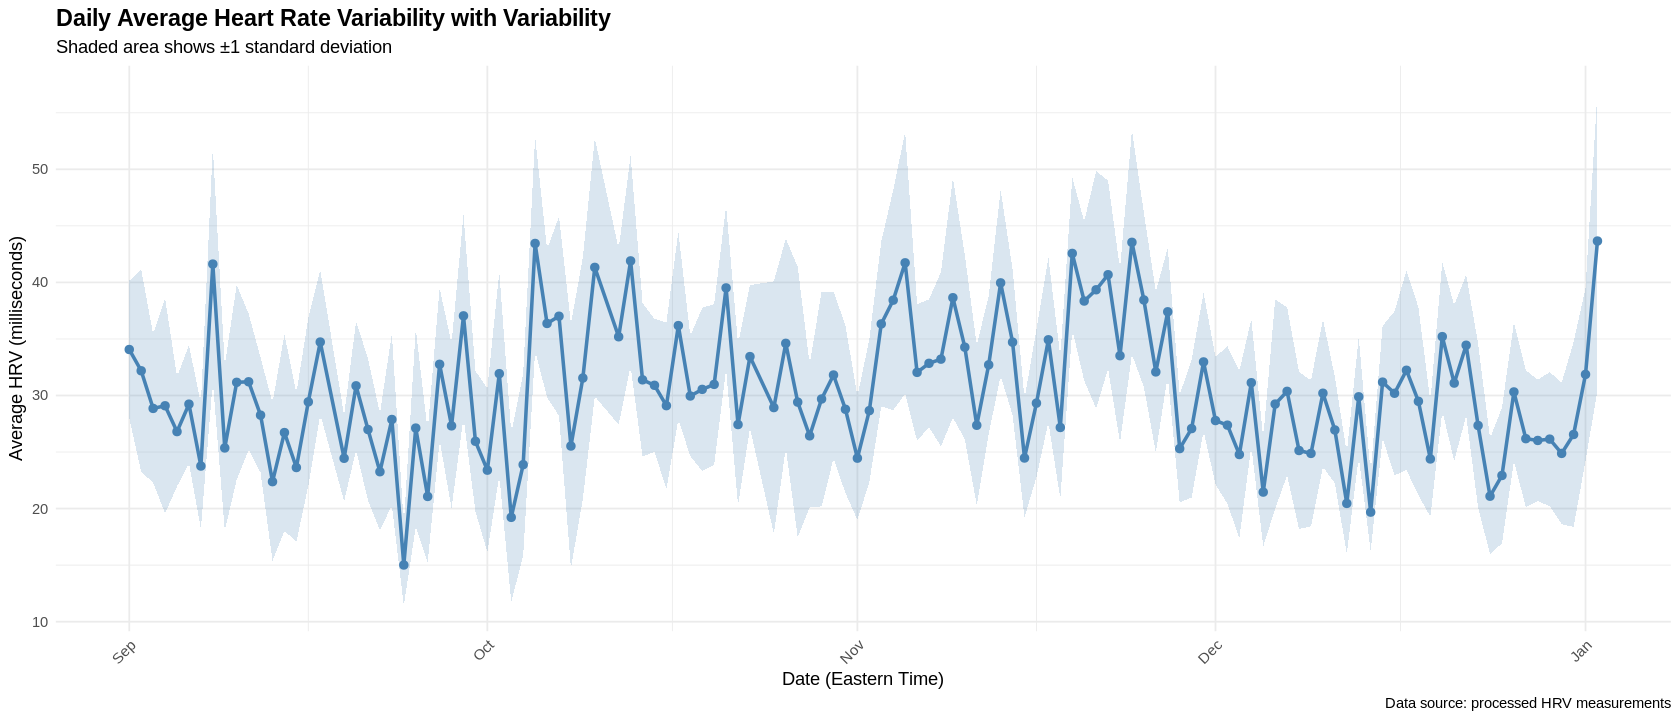

In [190]:
# ctrl + U   -> exposes the html code behind a website html
#$$
# THIS IS A NEW PLOT
# Set plot dimensions to be wider
options(repr.plot.width = 14, repr.plot.height = 6)
# Create daily HRV summary statistics from daty dataframe
daily_hrv_summary <- daty %>%
  mutate(calendarDate = as.Date(calendarDate)) %>%  # Ensure date is in Date format
  group_by(calendarDate) %>%
  summarise(
    mean_hrv = mean(hrvValue, na.rm = TRUE),        # Calculate average HRV per day
    median_hrv = median(hrvValue, na.rm = TRUE),    # Calculate median HRV per day
    min_hrv = min(hrvValue, na.rm = TRUE),          # Calculate minimum HRV per day
    max_hrv = max(hrvValue, na.rm = TRUE),          # Calculate maximum HRV per day
    sd_hrv = sd(hrvValue, na.rm = TRUE),            # Calculate standard deviation per day
    n = n(),                                         # Count number of HRV readings per day
    .groups = 'drop'
  )

# Create daily HRV summary visualization
daily_hrv_plot <- daily_hrv_summary %>%
  ggplot(aes(x = calendarDate, y = mean_hrv)) +    # Map date to x-axis, mean HRV to y-axis
  geom_line(color = "steelblue", size = 1) +       # Connect daily averages with line
  geom_point(color = "steelblue", size = 2) +      # Add points at each daily average
  geom_ribbon(
    aes(ymin = mean_hrv - sd_hrv, ymax = mean_hrv + sd_hrv),  # Create band showing ±1 SD
    alpha = 0.2,                                    # Make ribbon semi-transparent
    fill = "steelblue"                              # Use same color as line
  ) +
  labs(
    title = "Daily Average Heart Rate Variability with Variability",  # Main plot title
    subtitle = "Shaded area shows ±1 standard deviation",             # Explain the shaded region
    x = "Date (Eastern Time)",                                        # X-axis label
    y = "Average HRV (milliseconds)",                                 # Y-axis label
    caption = "Data source: processed HRV measurements"               # Data source attribution
  ) +
  theme_minimal() +                                 # Use minimal clean theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    plot.title = element_text(face = "bold", size = 14), # Bold title with larger font
    plot.subtitle = element_text(size = 11)              # Subtitle with standard font
  )

# Display the daily HRV plot
print(daily_hrv_plot)

In [191]:
# Create summary statistics for heart rate data
data_summary <- data %>%
  mutate(date_et = date(time)) %>%  # Extract date from time column in Eastern Time
  group_by(date_et) %>%  # Group measurements by date in Eastern Time
  summarise(
    mean_hr = mean(heartrate, na.rm = TRUE),      # Calculate average heart rate per day
    median_hr = median(heartrate, na.rm = TRUE),  # Calculate median heart rate per day
    min_hr = min(heartrate, na.rm = TRUE),        # Calculate minimum heart rate per day
    max_hr = max(heartrate, na.rm = TRUE),        # Calculate maximum heart rate per day
    sd_hr = sd(heartrate, na.rm = TRUE),          # Calculate standard deviation per day
    n = n(),                                       # Count number of measurements per day
    .groups = 'drop'  # Drop grouping after summarization
  )

# Track data_summary dataframe with description
fx(data_summary, "data_summary contains daily heart rate statistics aggregated from data")

In [192]:
#print(data_summary)

In [193]:
#print(tail(data_summary))

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_line()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”


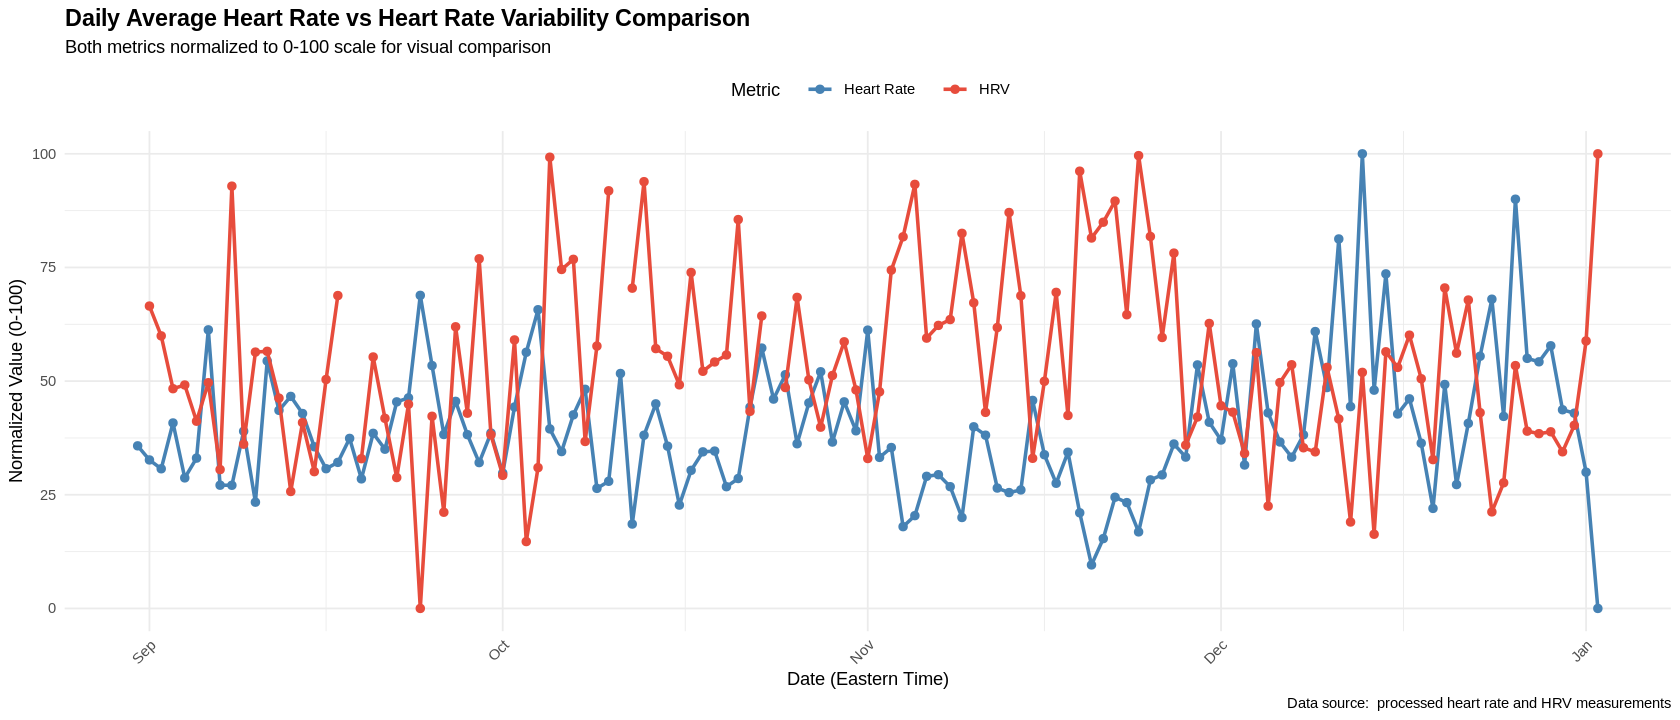

In [194]:
#$$
# Set plot dimensions to be wider
options(repr.plot.width = 14, repr.plot.height = 6)
# Create combined daily summary dataframe with both HR and HRV metrics
combined_summary <- data_summary %>%
  rename(date = date_et) %>%
  left_join(daily_hrv_summary, by = c("date" = "calendarDate"))

# Normalize both metrics to 0-100 scale for visual comparison on same plot
combined_summary <- combined_summary %>%
  mutate(
    mean_hr_normalized = (mean_hr - min(mean_hr, na.rm = TRUE)) /
      (max(mean_hr, na.rm = TRUE) - min(mean_hr, na.rm = TRUE)) * 100,
    mean_hrv_normalized = (mean_hrv - min(mean_hrv, na.rm = TRUE)) /
      (max(mean_hrv, na.rm = TRUE) - min(mean_hrv, na.rm = TRUE)) * 100
  )

# Create overlayed comparison plot with dual metrics
combined_plot <- combined_summary %>%
  ggplot(aes(x = date)) +
  # Heart Rate line in blue
  geom_line(aes(y = mean_hr_normalized, color = "Heart Rate"), size = 1) +
  geom_point(aes(y = mean_hr_normalized, color = "Heart Rate"), size = 2) +
  # HRV line in red
  geom_line(aes(y = mean_hrv_normalized, color = "HRV"), size = 1) +
  geom_point(aes(y = mean_hrv_normalized, color = "HRV"), size = 2) +
  scale_color_manual(values = c("Heart Rate" = "steelblue", "HRV" = "#E74C3C")) +
  labs(
    title = "Daily Average Heart Rate vs Heart Rate Variability Comparison",
    subtitle = "Both metrics normalized to 0-100 scale for visual comparison",
    x = "Date (Eastern Time)",
    y = "Normalized Value (0-100)",
    color = "Metric",
    caption = "Data source:  processed heart rate and HRV measurements"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 11),
    legend.position = "top"
  )

# Display the combined plot
print(combined_plot)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Failed to fit group -1.
Caused by error in `predLoess()`:
! workspace required (11300340155) is too large probably because of setting 'se = TRUE'.”


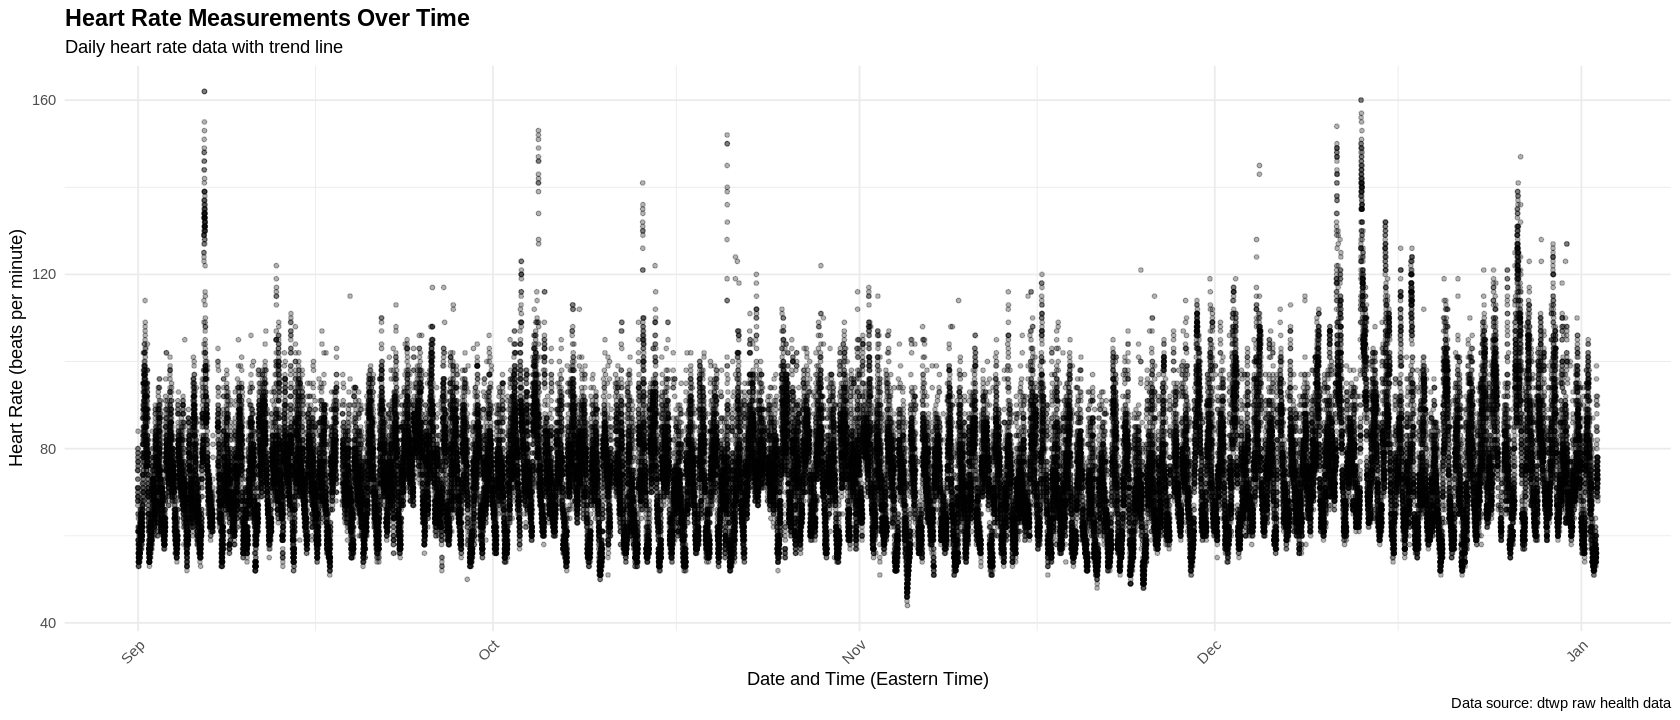

In [195]:


#$$
# Display first few rows of heart rate summary statistics
#show_tb(data_summary, 10)

#$$
# Create visualization of heart rate trends over time
hr_plot <- data %>%
  ggplot(aes(x = time, y = heartrate)) +  # Map time to x-axis, heart rate to y-axis
  geom_point(alpha = 0.3, size = 1) +         # Add points with transparency to show density
  geom_smooth(method = "loess", se = TRUE) +  # Add LOESS smoothing line with confidence interval
  labs(
    title = "Heart Rate Measurements Over Time",           # Main plot title
    subtitle = "Daily heart rate data with trend line",    # Descriptive subtitle
    x = "Date and Time (Eastern Time)",                    # X-axis label
    y = "Heart Rate (beats per minute)",                   # Y-axis label
    caption = "Data source: dtwp raw health data"          # Data source attribution
  ) +
  theme_minimal() +                           # Use minimal clean theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    plot.title = element_text(face = "bold", size = 14),  # Bold title with larger font
    plot.subtitle = element_text(size = 11)               # Subtitle with standard font
  )

# Display the heart rate plot
print(hr_plot)

In [196]:
tail(data_summary)
tail(daily_hrv_summary)

date_et,mean_hr,median_hr,min_hr,max_hr,sd_hr,n
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2025-12-28,78.01667,78,59,128,12.516793,720
2025-12-29,79.05139,76,59,127,14.697747,720
2025-12-30,74.92500,72,59,127,10.978038,720
2025-12-31,74.70556,73,58,110,9.923881,720
2026-01-01,70.90139,68,53,105,12.435983,720
2026-01-02,62.11661,57,51,99,10.216652,283


calendarDate,mean_hrv,median_hrv,min_hrv,max_hrv,sd_hrv,n
<date>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>
2025-12-28,26.02469,27.0,17,48,5.368834,81
2025-12-29,26.14286,26.0,13,39,5.922900,70
2025-12-30,24.88000,25.0,14,40,6.251400,75
2025-12-31,26.55085,24.5,13,49,8.177097,118
2026-01-01,31.86538,33.0,19,45,7.628710,52
2026-01-02,43.65854,44.0,21,79,13.226628,82


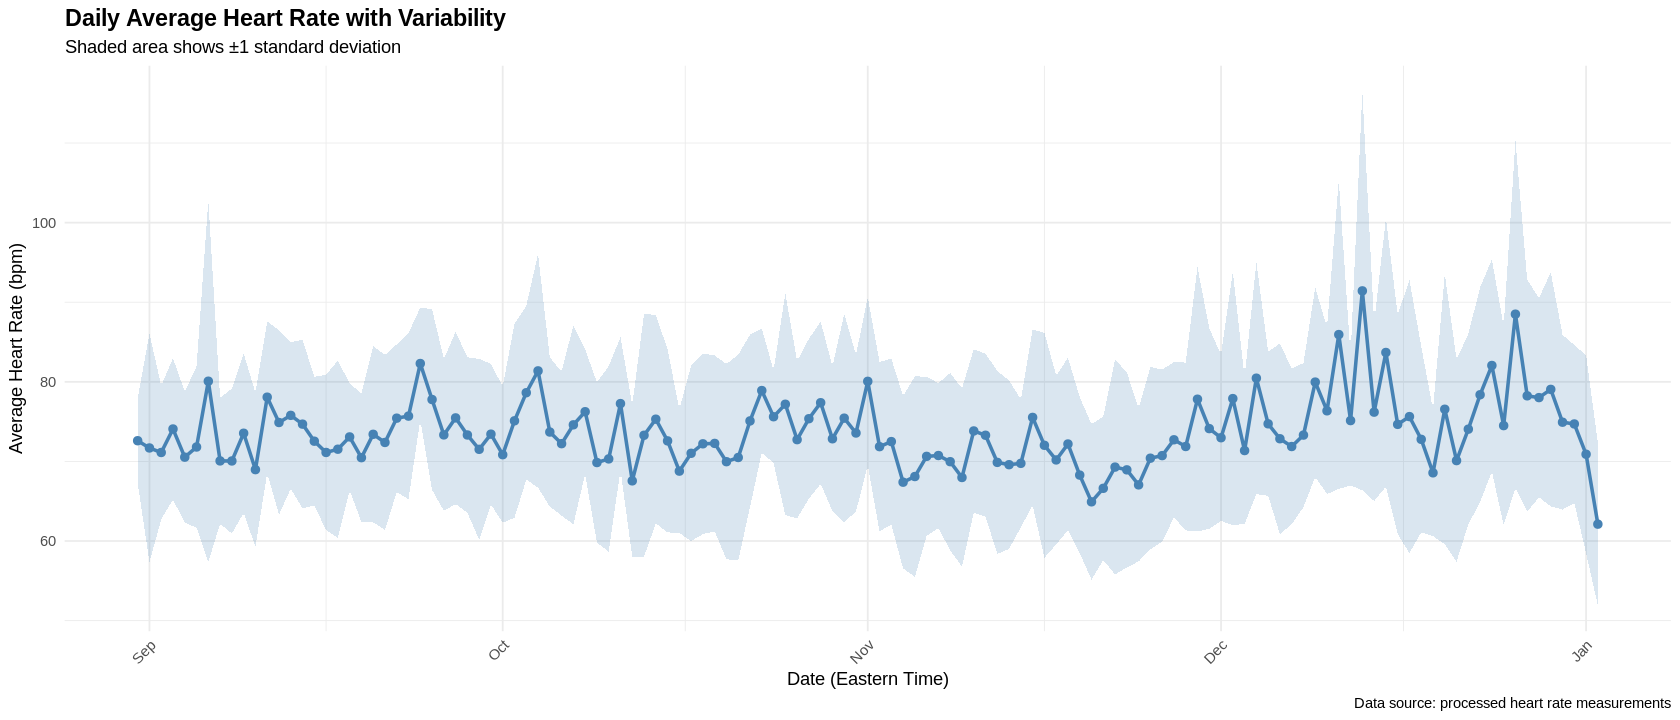

In [197]:
#$$
# Create daily heart rate summary visualization
daily_hr_plot <- data_summary %>%
  ggplot(aes(x = date_et, y = mean_hr)) +           # Map date to x-axis, mean heart rate to y-axis
  geom_line(color = "steelblue", size = 1) +        # Connect daily averages with line
  geom_point(color = "steelblue", size = 2) +       # Add points at each daily average
  geom_ribbon(
    aes(ymin = mean_hr - sd_hr, ymax = mean_hr + sd_hr),  # Create band showing ±1 SD
    alpha = 0.2,                                     # Make ribbon semi-transparent
    fill = "steelblue"                               # Use same color as line
  ) +
  labs(
    title = "Daily Average Heart Rate with Variability",  # Main plot title
    subtitle = "Shaded area shows ±1 standard deviation", # Explain the shaded region
    x = "Date (Eastern Time)",                            # X-axis label
    y = "Average Heart Rate (bpm)",                       # Y-axis label
    caption = "Data source: processed heart rate measurements"  # Data source attribution
  ) +
  theme_minimal() +                                  # Use minimal clean theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    plot.title = element_text(face = "bold", size = 14), # Bold title with larger font
    plot.subtitle = element_text(size = 11)              # Subtitle with standard font
  )

# Display the daily heart rate plot
print(daily_hr_plot)

In [198]:
#$$
# Export processed heart rate data to CSV file
write.csv(data,
           file = "heart_rate_processed.csv",  # Output filename
           row.names = FALSE)                   # Exclude row numbers from output

# Export daily summary statistics to CSV file
write.csv(data_summary,
          file = "heart_rate_daily_summary.csv",  # Output filename
          row.names = FALSE)                       # Exclude row numbers from output

# Print confirmation messages
message("Exported processed heart rate data to:  heart_rate_processed.csv")
message("Exported daily summary statistics to: heart_rate_daily_summary.csv")

#$$
# Display final summary of all tracked dataframes
print(all_names)

Exported processed heart rate data to:  heart_rate_processed.csv

Exported daily summary statistics to: heart_rate_daily_summary.csv



      dataframe
1          dtwp
2            de
3         dtwp1
4         dtwp2
5          data
6           de1
7            dg
8           dg1
9      dg2_proc
10     dg2_flat
11     dg3_flat
12         daty
13  daily_lines
14 data_summary
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                columns
1                                                                                                                                                               

In [199]:
#$$
# Display comments for each tracked dataframe
cat("=== DATAFRAME TRACKING SUMMARY ===\n\n")

for (i in 1:nrow(all_names)) {
  # Print dataframe name as header
  cat("Dataframe: ", all_names$dataframe[i], "\n")

  # Print associated columns
  cat("Columns:  ", all_names$columns[i], "\n")

  # Print associated comments if they exist
  if (all_names$comment[i] != "") {
    cat("Comments:\n", all_names$comment[i], "\n")
  } else {
    cat("Comments:  None\n")
  }

  # Print separator line between dataframes
  cat("\n---\n\n")
}

#$$
# Create a final report document summarizing the analysis
report <- paste(
  "HEART RATE DATA ANALYSIS REPORT",
  "================================\n",
  "Generated:  ", format(Sys.time(), "%Y-%m-%d %H:%M:%S"), "\n\n",

  "DATA PROCESSING SUMMARY:",
  "------------------------",
  "1.  Extracted heart rate and calendar date from raw df",
  "2. Parsed JSON heart rate values from string format",
  "3. Unnested heart rate data into individual measurements",
  "4. Converted millisecond timestamps to readable datetime",
  "5. Converted UTC times to Eastern Time Zone",
  "6. Extracted date component for daily aggregation\n",

  "DESCRIPTIVE STATISTICS:",
  "------------------------",
  paste("Total measurements:  ", nrow(data)),
  paste("Date range: ", min(data$date_et), " to ", max(data$date_et)),
  paste("Overall mean heart rate: ", round(mean(data$heartrate, na.rm = TRUE), 2), " bpm"),
  paste("Overall median heart rate: ", round(median(data$heartrate, na.rm = TRUE), 2), " bpm"),
  paste("Overall min heart rate: ", min(data$heartrate, na.rm = TRUE), " bpm"),
  paste("Overall max heart rate: ", max(data$heartrate, na.rm = TRUE), " bpm\n"),

  "FILES GENERATED:",
  "------------------------",
  "- heart_rate_processed.csv (detailed measurements)",
  "- heart_rate_daily_summary.csv (daily statistics)",
  "- hr_plot (time series visualization)",
  "- daily_hr_plot (daily average trends)\n",

  sep = "\n"
)

# Print the report
cat(report)

# Optionally save report to text file
writeLines(report, "heart_rate_analysis_report.txt")
message("\nReport saved to:  heart_rate_analysis_report.txt")

#$$
# Session cleanup and final notes
cat("\n=== ANALYSIS COMPLETE ===\n\n")

cat("Key Findings:\n")
cat("- Heart rate data successfully processed and organized\n")
cat("- Data converted from UTC to Eastern Time Zone\n")
cat("- Daily summaries calculated with statistical measures\n")
cat("- Visualizations created showing trends and variability\n\n")

cat("All dataframes tracked in 'all_names':\n")
print(all_names$dataframe)

cat("\nTo review any dataframe's description, use:\n")
cat("  df_comms(dataframe_name)\n\n")

cat("To see all current dataframes, use:\n")
cat("  curr_df()\n\n")

cat("To reset tracking, use:\n")
cat("  reset_fx()\n\n")

cat("Analysis workflow complete. All outputs saved.\n")

=== DATAFRAME TRACKING SUMMARY ===

Dataframe:  dtwp 
Columns:   calendarDate, heartRateValues 
Comments:
 takes these 2 columns from df - CLEANED 

---

Dataframe:  de 
Columns:   summaryDate, userProfilePK, calendarDate, startTimestampGMT, endTimestampGMT, startTimestampLocal, endTimestampLocal, maxHeartRate, minHeartRate, restingHeartRate, lastSevenDaysAvgRestingHeartRate, userProfilePk, hrvSummary, hrvReadings, sleepStartTimestampGMT, sleepEndTimestampGMT, sleepStartTimestampLocal, sleepEndTimestampLocal, tomorrowSleepStartTimestampGMT, tomorrowSleepEndTimestampGMT, tomorrowSleepStartTimestampLocal, tomorrowSleepEndTimestampLocal, lowestRespirationValue, highestRespirationValue, avgWakingRespirationValue, avgSleepRespirationValue, avgTomorrowSleepRespirationValue 
Comments:
 de takes everything from df except heartRateValues and heartRateValueDescriptors 

---

Dataframe:  dtwp1 
Columns:   calendarDate, heartRateValues 
Comments:
 dtwp1 parses JSON - WITH ERROR HANDLING 

---

Dat

Warning message in min(data$date_et):
“no non-missing arguments to min; returning Inf”
Warning message in max(data$date_et):
“no non-missing arguments to max; returning -Inf”


HEART RATE DATA ANALYSIS REPORT

Generated:  
2026-01-02 19:41:37



DATA PROCESSING SUMMARY:
------------------------
1.  Extracted heart rate and calendar date from raw df
2. Parsed JSON heart rate values from string format
3. Unnested heart rate data into individual measurements
4. Converted millisecond timestamps to readable datetime
5. Converted UTC times to Eastern Time Zone
6. Extracted date component for daily aggregation

DESCRIPTIVE STATISTICS:
------------------------
Total measurements:   86793
Date range:  Inf  to  -Inf
Overall mean heart rate:  73.8  bpm
Overall median heart rate:  73  bpm
Overall min heart rate:  44  bpm
Overall max heart rate:  162  bpm

FILES GENERATED:
------------------------
- heart_rate_processed.csv (detailed measurements)
- heart_rate_daily_summary.csv (daily statistics)
- hr_plot (time series visualization)
- daily_hr_plot (daily average trends)



Report saved to:  heart_rate_analysis_report.txt




=== ANALYSIS COMPLETE ===

Key Findings:
- Heart rate data successfully processed and organized
- Data converted from UTC to Eastern Time Zone
- Daily summaries calculated with statistical measures
- Visualizations created showing trends and variability

All dataframes tracked in 'all_names':
 [1] "dtwp"         "de"           "dtwp1"        "dtwp2"        "data"         "de1"          "dg"           "dg1"          "dg2_proc"     "dg2_flat"     "dg3_flat"     "daty"         "daily_lines"  "data_summary"

To review any dataframe's description, use:
  df_comms(dataframe_name)

To see all current dataframes, use:
  curr_df()

To reset tracking, use:
  reset_fx()

Analysis workflow complete. All outputs saved.


In [ ]:
# Simple keep-alive loop - print every 2 seconds with counter
for (i in 1:1000) {
  cat("\r", "cat", i)
  flush.console()
  Sys.sleep(10)
}

 cat 63